# Notebook 6 — Финальное сравнение методов

**Цель ноутбука:**  
Загрузить скоры всех реализованных методов из `results/`,
построить единую сравнительную таблицу метрик, визуализации
и сформулировать итоговые выводы.

**Методы:**

| Категория | Метод | Источник |
|---|---|---|
| Baseline | Logistic Regression | Notebook 2 |
| Baseline |  версии LightGBM | Notebook 2 |
| Матричная факторизация | CTKT | Notebook 3 |
| Матричная факторизация | GiPM3F | Notebook 3 |
| Графовые | GraphRfi | Notebook 4 |
| Графовые | EthAegis | Notebook 4 |
| Последовательные | SPADE | Notebook 5 |
| Последовательные | CLUE | Notebook 5 |
| Последовательные | NHFM | Notebook 5 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    ndcg_score, precision_recall_curve,
    roc_curve,
)

RESULTS = Path("../results")

plt.rcParams["figure.dpi"]  = 130
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")

# Цвета и метки для каждого метода
METHOD_META = {
    "lr":       {"label": "Logistic Regression", "color": "#94A3B8",
                 "category": "Baseline",              "marker": "o"},
    "lgbm":     {"label": "LightGBM",             "color": "#1D4ED8",
                 "category": "Baseline",              "marker": "s"},
    "ctkt":     {"label": "CTKT",                 "color": "#D97706",
                 "category": "Матричная факторизация", "marker": "^"},
    "gipm3f":   {"label": "GiPM3F",               "color": "#F59E0B",
                 "category": "Матричная факторизация", "marker": "v"},
    "graphrfi": {"label": "GraphRfi",             "color": "#7C3AED",
                 "category": "Графовые",              "marker": "D"},
    "ethaegis": {"label": "EthAegis",             "color": "#A78BFA",
                 "category": "Графовые",              "marker": "P"},
    "spade":    {"label": "SPADE",                "color": "#059669",
                 "category": "Последовательные",      "marker": "h"},
    "clue":     {"label": "CLUE",                 "color": "#DC2626",
                 "category": "Последовательные",      "marker": "*"},
    "nhfm":     {"label": "NHFM",                 "color": "#16A34A",
                 "category": "Последовательные",      "marker": "X"},
    "lgbm_velocity": {"label": "LightGBM-velocity", "color": "#F4A261",
                      "category": "Baseline",       "marker": "p"},
    "lgbm_44":       {"label": "LightGBM-44",       "color": "#2A9D8F",
                      "category": "Baseline",       "marker": "h"},
}

In [2]:
print("Загружаем скоры всех методов...\n")

scores_dict = {}
missing     = []

for method in METHOD_META:
    path = RESULTS / f"scores_{method}.csv"
    if path.exists():
        df = pd.read_csv(path)
        scores_dict[method] = df
        print(f"  ✓ {method:<10} "
              f"строк={len(df):,}  "
              f"фрода={df['y_true'].sum():,}  "
              f"скор min={df['score'].min():.3f}  "
              f"max={df['score'].max():.3f}")
    else:
        missing.append(method)
        print(f"  ✗ {method} — файл не найден")

print(f"\nЗагружено: {len(scores_dict)}/{len(METHOD_META)} методов")
if missing:
    print(f"Отсутствуют: {missing}")

Загружаем скоры всех методов...

  ✓ lr         строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ lgbm       строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ ctkt       строк=555,719  фрода=2,145  скор min=0.054  max=0.949
  ✓ gipm3f     строк=555,719  фрода=2,145  скор min=0.445  max=1.282
  ✓ graphrfi   строк=555,719  фрода=2,145  скор min=0.005  max=0.500
  ✓ ethaegis   строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ spade      строк=555,719  фрода=2,145  скор min=0.500  max=1.000
  ✓ clue       строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ nhfm       строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ lgbm_velocity строк=555,719  фрода=2,145  скор min=0.000  max=1.000
  ✓ lgbm_44    строк=555,719  фрода=2,145  скор min=0.000  max=1.000

Загружено: 11/11 методов


In [3]:
def compute_metrics(
    y_true: np.ndarray,
    scores: np.ndarray,
    k_list: list = [100, 500],
) -> dict:
    results = {}

    results["roc_auc"] = roc_auc_score(y_true, scores)
    results["pr_auc"]  = average_precision_score(y_true, scores)

    prec_c, rec_c, thr = precision_recall_curve(y_true, scores)
    f1_c      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
    best_idx  = f1_c.argmax()
    threshold = thr[best_idx]
    y_pred    = (scores >= threshold).astype(int)

    results["threshold"] = threshold
    results["precision"] = precision_score(y_true, y_pred, zero_division=0)
    results["recall"]    = recall_score(y_true,    y_pred, zero_division=0)
    results["f1"]        = f1_score(y_true,        y_pred, zero_division=0)

    n_fraud   = y_true.sum()
    ranked    = np.argsort(scores)[::-1]
    y_ranked  = y_true[ranked]

    for k in k_list:
        top_k              = y_ranked[:k]
        fraud_in_k         = top_k.sum()
        results[f"p@{k}"]  = fraud_in_k / k
        results[f"r@{k}"]  = fraud_in_k / n_fraud
        results[f"ndcg@{k}"] = ndcg_score(
            y_true.reshape(1, -1),
            scores.reshape(1, -1),
            k=k,
        )

    return results


print("Вычисляем метрики для всех методов...\n")

metrics_rows = []
for method, df in scores_dict.items():
    y_true = df["y_true"].values
    scores = df["score"].values
    m      = compute_metrics(y_true, scores)
    m["method"]   = method
    m["label"]    = METHOD_META[method]["label"]
    m["category"] = METHOD_META[method]["category"]
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("method")

# Форматированная таблица
display_cols = [
    "label", "category",
    "roc_auc", "pr_auc", "f1",
    "p@100", "ndcg@100", "p@500", "ndcg@500",
]

metrics_df[display_cols].sort_values("pr_auc", ascending=False)

Вычисляем метрики для всех методов...



,label,category,roc_auc,pr_auc,f1,p@100,ndcg@100,p@500,ndcg@500
method,,,,,,,,,
lgbm_44,LightGBM-44,Baseline,0.995001,0.885276,0.832538,1.00,1.000000,1.000,1.000000
clue,CLUE,Последовательные,0.991457,0.809112,0.773148,1.00,1.000000,0.998,0.998302
lgbm_velocity,LightGBM-velocity,Baseline,0.969227,0.732528,0.720828,1.00,1.000000,0.988,0.990028
nhfm,NHFM,Последовательные,0.983252,0.707798,0.684639,0.99,0.989442,0.978,0.979986
lgbm,LightGBM,Baseline,0.903304,0.545713,0.576532,1.00,1.000000,0.950,0.958747
lr,Logistic Regression,Baseline,0.931149,0.132227,0.304191,0.00,0.000000,0.018,0.018179
graphrfi,GraphRfi,Графовые,0.544514,0.084276,0.141248,1.00,1.000000,0.344,0.439526
spade,SPADE,Последовательные,0.618747,0.075104,0.153999,0.65,0.660078,0.388,0.428573
ctkt,CTKT,Матричная факторизация,0.894046,0.068143,0.144870,0.26,0.245705,0.166,0.173906


**Оценка устойчивости метрик**

Метрики вычислены на одной тестовой выборке, поэтому сами по себе не позволяют судить о том, насколько различия между методами устойчивы к её составу. Для оценки разброса применяется бутстрэп: тестовая выборка 1000 раз пересобирается с возвращением, на каждой псевдовыборке метрика пересчитывается, после чего по перцентилям 2,5 % и 97,5 % строится 95%-й доверительный интервал. Модели при этом не переобучаются — процедура работает поверх готовых скоров.

In [4]:
from joblib import Parallel, delayed

def bootstrap_ci(y_true, scores, metric_fn, n_boot=1000, seed=42, n_jobs=-1):
    """95% доверительный интервал метрики через бутстрэп тестовой выборки."""
    n = len(y_true)
    def one_iter(i):
        rng = np.random.default_rng(seed + i)
        idx = rng.integers(0, n, n)
        return metric_fn(y_true[idx], scores[idx])
    vals = Parallel(n_jobs=n_jobs)(delayed(one_iter)(i) for i in range(n_boot))
    return np.percentile(vals, [2.5, 97.5])

print("Считаем доверительные интервалы (1000 ресэмплов)...\n")

ci_rows = []
for method, df in scores_dict.items():
    y, s = df["y_true"].values, df["score"].values
    pr_lo, pr_hi   = bootstrap_ci(y, s, average_precision_score)
    roc_lo, roc_hi = bootstrap_ci(y, s, roc_auc_score)
    ci_rows.append({
        "method":  method,
        "label":   METHOD_META[method]["label"],
        "pr_auc":  average_precision_score(y, s),
        "pr_ci":   f"[{pr_lo:.3f}, {pr_hi:.3f}]",
        "roc_auc": roc_auc_score(y, s),
        "roc_ci":  f"[{roc_lo:.3f}, {roc_hi:.3f}]",
    })
    print(f"  ✓ {method}")

ci_df = pd.DataFrame(ci_rows).set_index("method").sort_values("pr_auc", ascending=False)
ci_df.to_csv(RESULTS / "metrics_with_ci.csv")
ci_df

Считаем доверительные интервалы (1000 ресэмплов)...



/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ✓ lr


/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ✓ lgbm
  ✓ ctkt
  ✓ gipm3f
  ✓ graphrfi
  ✓ ethaegis
  ✓ spade


...

/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ✓ lgbm_velocity


/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ✓ lgbm_44


,label,pr_auc,pr_ci,roc_auc,roc_ci
method,,,,,
lgbm_44,LightGBM-44,0.885276,"[0.874, 0.896]",0.995001,"[0.994, 0.996]"
clue,CLUE,0.809112,"[0.793, 0.824]",0.991457,"[0.989, 0.993]"
lgbm_velocity,LightGBM-velocity,0.732528,"[0.715, 0.751]",0.969227,"[0.964, 0.974]"
nhfm,NHFM,0.707798,"[0.688, 0.726]",0.983252,"[0.980, 0.986]"
lgbm,LightGBM,0.545713,"[0.525, 0.567]",0.903304,"[0.894, 0.913]"
lr,Logistic Regression,0.132227,"[0.123, 0.142]",0.931149,"[0.926, 0.936]"
graphrfi,GraphRfi,0.084276,"[0.072, 0.095]",0.544514,"[0.532, 0.557]"
spade,SPADE,0.075104,"[0.063, 0.089]",0.618747,"[0.603, 0.634]"
ctkt,CTKT,0.068143,"[0.062, 0.076]",0.894046,"[0.888, 0.901]"


Доверительные интервалы позволяют упорядочить лидирующие модели без пересечений.
Интервал LightGBM-44 по PR-AUC [0,874; 0,896] лежит целиком выше интервала CLUE
[0,793; 0,824]: добавление velocity-признаков не только закрывает разрыв между
градиентным бустингом и лучшим последовательным методом, но и выводит бустинг
вперёд. Интервал CLUE, в свою очередь, целиком выше интервала LightGBM-velocity
[0,715; 0,751] — нейросетевое моделирование порядка событий на пяти сырых
атрибутах превосходит бустинг на двенадцати сконструированных временны́х
признаках. Наконец, обе новые конфигурации значимо превосходят статический
LightGBM [0,525; 0,567].

Таким образом, устойчивой к составу тестовой выборки является вся иерархия:
комбинация статического и временно́го сигнала > явное моделирование порядка >
временны́е агрегаты > статические агрегаты. Содержательно это означает, что
решающим фактором качества на данных Sparkov является доступ модели
к временно́й динамике поведения держателя, а не класс архитектуры сам по себе.
Более строгая проверка значимости попарных различий (парный бутстрэп разностей)
приведена ниже.

## Парный бутстрэп разностей PR-AUC

Непересечение индивидуальных доверительных интервалов — достаточное, но
консервативное свидетельство значимости различия. Более строгая процедура —
**парный бутстрэп разности**: обе модели оцениваются на одних и тех же
ресэмплах тестовой выборки, и 95%-й интервал строится непосредственно для
разности PR-AUC. Если ноль лежит вне интервала, различие значимо на уровне 5%.

Ключевые пары: вклад velocity-признаков относительно статики; сравнение
лучшего последовательного метода (CLUE) с тремя конфигурациями бустинга;
сравнение LightGBM-44 с обоими последовательными лидерами.

In [5]:
# Парный бутстрэп разностей PR-AUC (общие ресэмплы)
from joblib import Parallel, delayed

def paired_bootstrap_delta(y_true, scores_a, scores_b, metric_fn,
                           n_boot=1000, seed=42, n_jobs=-1):
    """95% CI для metric(A) - metric(B) на общих ресэмплах."""
    n = len(y_true)
    def one(i):
        rng = np.random.default_rng(seed + i)
        idx = rng.integers(0, n, n)
        return metric_fn(y_true[idx], scores_a[idx]) - \
               metric_fn(y_true[idx], scores_b[idx])
    vals = Parallel(n_jobs=n_jobs)(delayed(one)(i) for i in range(n_boot))
    return np.percentile(vals, [2.5, 97.5])

y_np = scores_dict["lgbm"]["y_true"].values
S = {m: scores_dict[m]["score"].values for m in scores_dict}

pairs = [
    ("clue",          "lgbm",          "CLUE − LGBM-32"),
    ("lgbm_velocity", "lgbm",          "LGBM-velocity − LGBM-32"),
    ("lgbm_44",       "lgbm",          "LGBM-44 − LGBM-32"),
    ("clue",          "lgbm_velocity", "CLUE − LGBM-velocity"),
    ("lgbm_44",       "clue",          "LGBM-44 − CLUE"),
    ("lgbm_44",       "nhfm",          "LGBM-44 − NHFM"),
]

print("Парный бутстрэп разностей PR-AUC (1000 общих ресэмплов):\n")
for a, b, label in pairs:
    if a in S and b in S:
        lo, hi = paired_bootstrap_delta(y_np, S[a], S[b],
                                        average_precision_score)
        signif = "значимо" if (lo > 0 or hi < 0) else "НЕ значимо"
        print(f"  {label:<28} [{lo:+.3f}, {hi:+.3f}]  {signif}")

Парный бутстрэп разностей PR-AUC (1000 общих ресэмплов):



/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CLUE − LGBM-32               [+0.230, +0.278]  значимо
  LGBM-velocity − LGBM-32      [+0.162, +0.211]  значимо
  LGBM-44 − LGBM-32            [+0.321, +0.359]  значимо
  CLUE − LGBM-velocity         [+0.052, +0.084]  значимо
  LGBM-44 − CLUE               [+0.070, +0.099]  значимо
  LGBM-44 − NHFM               [+0.169, +0.206]  значимо


## Асимметричные метрики: F-beta и денежно-взвешенный Recall@K

F1-мера симметрична по стоимости ошибок: ложное срабатывание и пропущенный
фрод входят в неё с равным весом. В условиях бизнес-задачи стоимости
асимметричны: пропущенный фрод (FN) — прямой финансовый ущерб в размере суммы
транзакции, ложная тревога (FP) — стоимость проверки алерта аналитиком.

Проверяем устойчивость выводов к асимметрии двумя способами:

1. **F-beta** при том же пороге, что и F1: β=2 (recall весит вчетверо больше
   precision — FN дороже FP, реалистичный антифрод-сценарий) и β=0,5
   (обратная асимметрия, для контроля).
2. **Денежно-взвешенный Recall@K** — доля предотвращённого ущерба: какая часть
   суммарного объёма мошеннических средств попадает в топ-K очереди алертов.
   Стоимость FN здесь равна сумме транзакции — асимметрия задаётся самими
   данными, без произвольных констант стоимости.

Полную cost-модель (цена часа аналитика и т.п.) сознательно не строим:
для синтетических данных такие константы были бы выдуманными; денежный
Recall@K даёт ту же асимметрию без дополнительных предположений.

In [6]:
# Асимметричные метрики поверх сохранённых скоров
from sklearn.metrics import fbeta_score

RAW = Path("../data/raw")

# Суммы транзакций из сырого test (порядок строк совпадает со скорами —
# проверяем тем же ассертом по is_fraud, что и в Notebook 2)
test_raw_amt = pd.read_csv(RAW / "fraudTest.csv", index_col=0,
                           usecols=lambda c: c in ("Unnamed: 0", "amt", "is_fraud"))
y_np = scores_dict["lgbm"]["y_true"].values
assert (test_raw_amt["is_fraud"].values == y_np).all(), \
    "Порядок строк fraudTest.csv не совпадает со скорами"
amt = test_raw_amt["amt"].values

total_fraud_amt = amt[y_np == 1].sum()
print(f"Суммарный ущерб в тестовой выборке: ${total_fraud_amt:,.0f} "
      f"({y_np.sum()} транзакций)\n")

rows = []
for method, df in scores_dict.items():
    scores = df["score"].values

    # Порог — максимум F1, та же процедура, что в основной таблице
    prec_c, rec_c, thr = precision_recall_curve(y_np, scores)
    f1_c = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
    threshold = thr[f1_c.argmax()]
    y_pred = (scores >= threshold).astype(int)

    row = {
        "method": method,
        "label":  METHOD_META[method]["label"],
        "f1":     f1_score(y_np, y_pred, zero_division=0),
        "f2":     fbeta_score(y_np, y_pred, beta=2,   zero_division=0),
        "f05":    fbeta_score(y_np, y_pred, beta=0.5, zero_division=0),
    }

    # Денежно-взвешенный Recall@K: доля предотвращённого ущерба в топ-K
    ranked = np.argsort(scores)[::-1]
    for k in (100, 500):
        top_k = ranked[:k]
        caught_amt = amt[top_k][y_np[top_k] == 1].sum()
        row[f"money_r@{k}"] = caught_amt / total_fraud_amt
        # для сопоставления — обычный (штучный) recall@k
        row[f"count_r@{k}"] = y_np[top_k].sum() / y_np.sum()
    rows.append(row)

asym_df = (pd.DataFrame(rows).set_index("method")
           .sort_values("f2", ascending=False))

print("Асимметричные метрики (порог = argmax F1):\n")
print(asym_df[["label", "f1", "f2", "f05",
               "count_r@500", "money_r@500"]].round(4).to_string())

# Проверка устойчивости ранжирования методов
order_f1  = asym_df["f1"].rank(ascending=False)
order_f2  = asym_df["f2"].rank(ascending=False)
order_f05 = asym_df["f05"].rank(ascending=False)
print(f"\nКорреляция Спирмена рангов: F1 vs F2 = "
      f"{order_f1.corr(order_f2, method='spearman'):.3f}, "
      f"F1 vs F0.5 = {order_f1.corr(order_f05, method='spearman'):.3f}")

asym_df.to_csv(RESULTS / "asymmetric_metrics.csv")
print("Сохранено: results/asymmetric_metrics.csv")

Суммарный ущерб в тестовой выборке: $1,133,325 (2145 транзакций)

Асимметричные метрики (порог = argmax F1):

                             label      f1      f2     f05  count_r@500  money_r@500
method                                                                              
lgbm_44                LightGBM-44  0.8325  0.8210  0.8444       0.2331       0.3047
clue                          CLUE  0.7690  0.7241  0.8199       0.2308       0.3524
lgbm_velocity    LightGBM-velocity  0.7208  0.6762  0.7717       0.2303       0.3752
nhfm                          NHFM  0.6811  0.6458  0.7204       0.2261       0.2972
lgbm                      LightGBM  0.5765  0.5206  0.6459       0.2214       0.2166
lr             Logistic Regression  0.3042  0.3517  0.2680       0.0042       0.0055
ctkt                          CTKT  0.1449  0.2113  0.1102       0.0387       0.0290
spade                        SPADE  0.1540  0.1228  0.2065       0.0904       0.1052
graphrfi                  GraphRfi  0.14

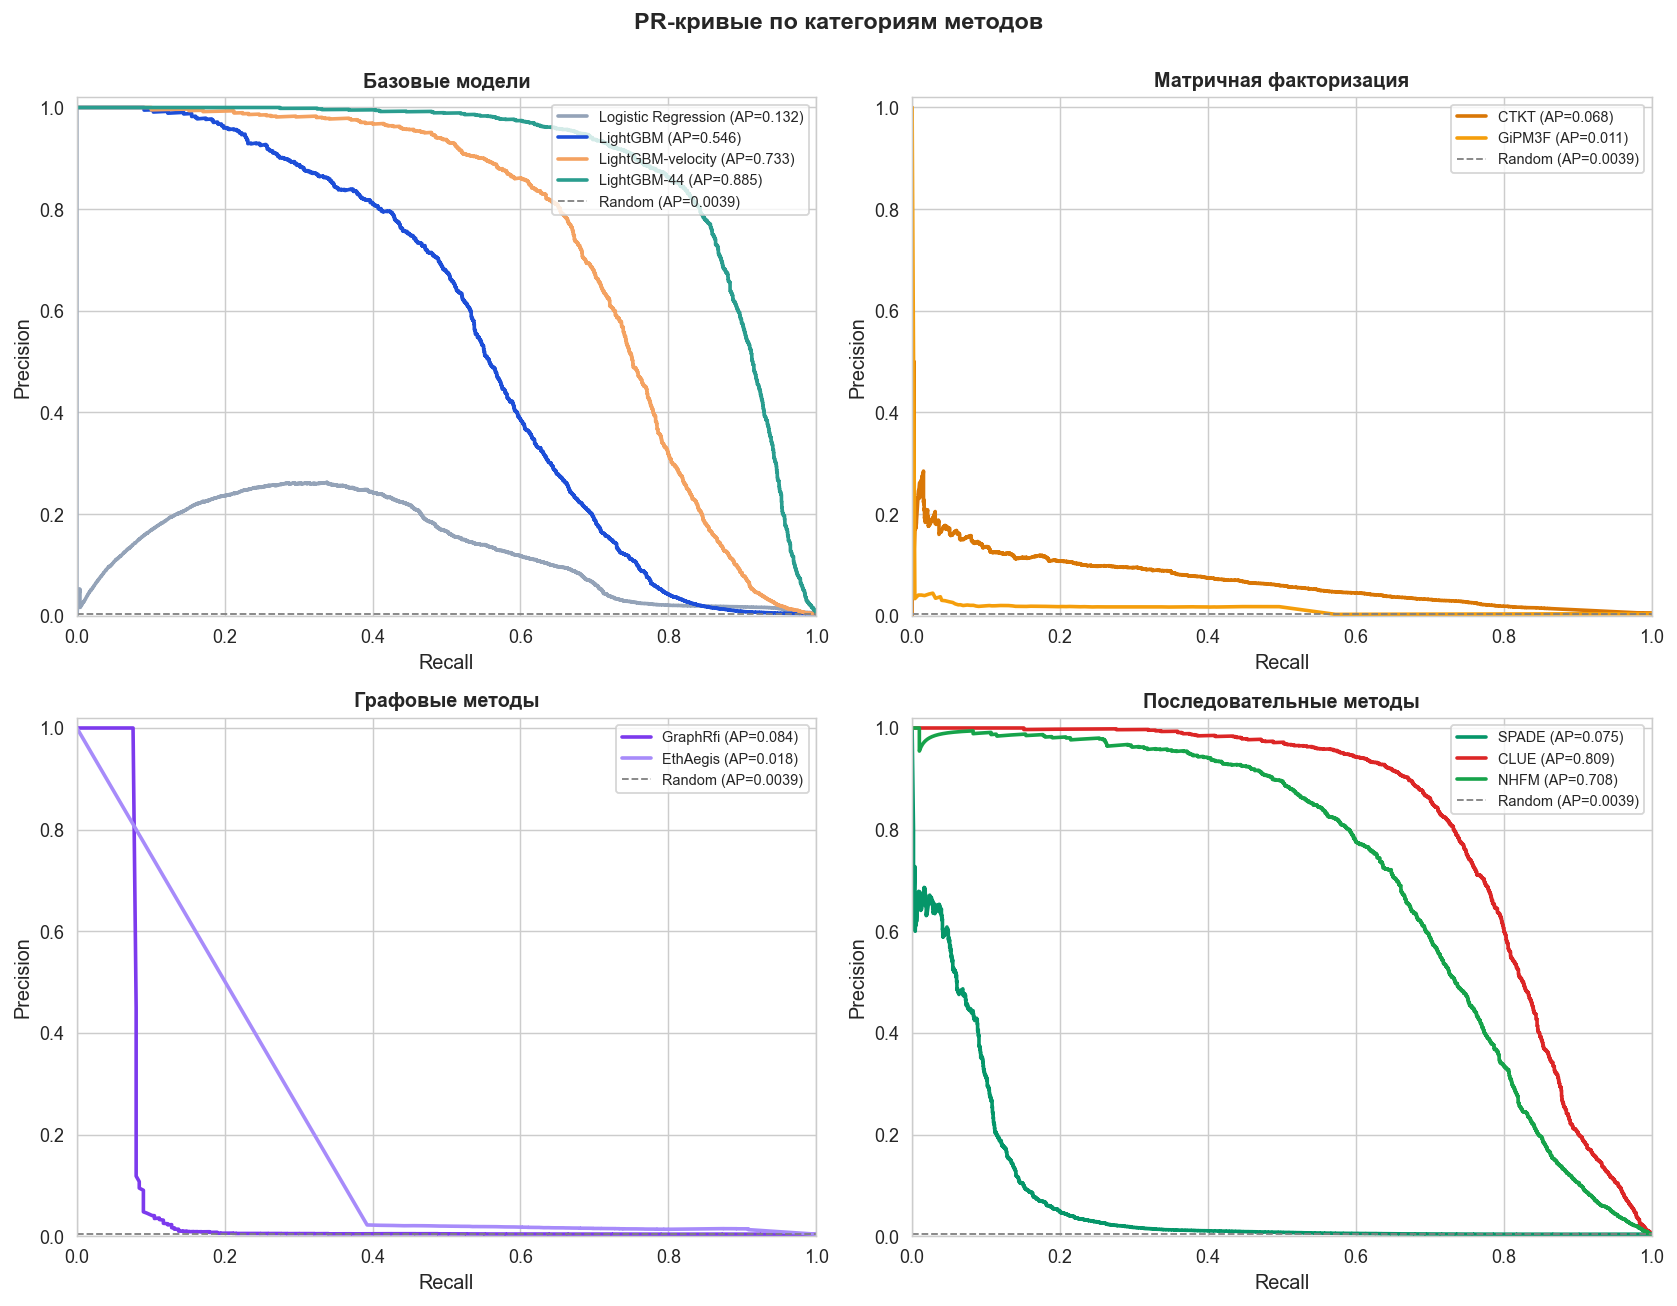

PR-кривые сохранены: results/pr_curves.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

categories = {
    "Базовые модели":         ["lr", "lgbm", "lgbm_velocity", "lgbm_44"],
    "Матричная факторизация": ["ctkt", "gipm3f"],
    "Графовые методы":        ["graphrfi", "ethaegis"],
    "Последовательные методы": ["spade", "clue", "nhfm"],
}

y_true_all = list(scores_dict.values())[0]["y_true"].values
baseline   = y_true_all.mean()

for ax, (title, methods) in zip(axes, categories.items()):
    for method in methods:
        if method not in scores_dict:
            continue
        df     = scores_dict[method]
        y_true = df["y_true"].values
        scores = df["score"].values
        prec, rec, _ = precision_recall_curve(y_true, scores)
        pr_auc = average_precision_score(y_true, scores)
        meta   = METHOD_META[method]

        ax.plot(
            rec, prec,
            color     = meta["color"],
            linewidth = 2,
            label     = f"{meta['label']} (AP={pr_auc:.3f})",
        )

    ax.axhline(baseline, color="gray", linestyle="--",
               linewidth=1, label=f"Random (AP={baseline:.4f})")

    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle("PR-кривые по категориям методов",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(RESULTS / "pr_curves.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("PR-кривые сохранены: results/pr_curves.png")

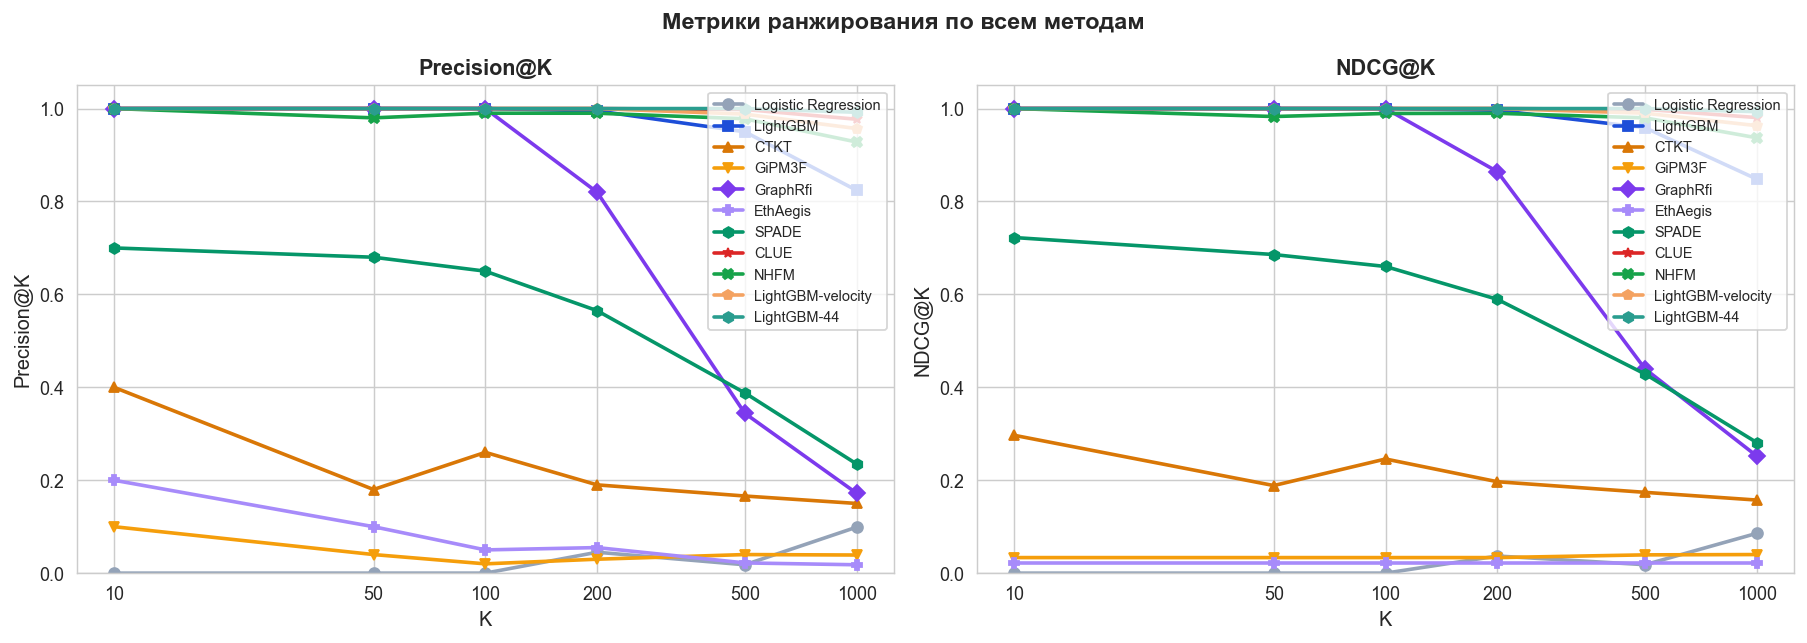

График метрик ранжирования сохранён: results/ranking_metrics.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_values = [10, 50, 100, 200, 500, 1000]

for ax, metric_name in zip(axes, ["Precision@K", "NDCG@K"]):
    for method, df in scores_dict.items():
        y_true  = df["y_true"].values
        scores  = df["score"].values
        ranked  = np.argsort(scores)[::-1]
        y_ranked = y_true[ranked]
        meta    = METHOD_META[method]

        values = []
        for k in k_values:
            if metric_name == "Precision@K":
                val = y_ranked[:k].sum() / k
            else:
                val = ndcg_score(
                    y_true.reshape(1, -1),
                    scores.reshape(1, -1),
                    k=k,
                )
            values.append(val)

        ax.plot(
            k_values, values,
            color     = meta["color"],
            marker    = meta["marker"],
            linewidth = 2,
            markersize = 6,
            label     = meta["label"],
        )

    ax.set_xlabel("K", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks(k_values)
    ax.set_ylim([0, 1.05])

plt.suptitle("Метрики ранжирования по всем методам",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "ranking_metrics.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("График метрик ранжирования сохранён: results/ranking_metrics.png")

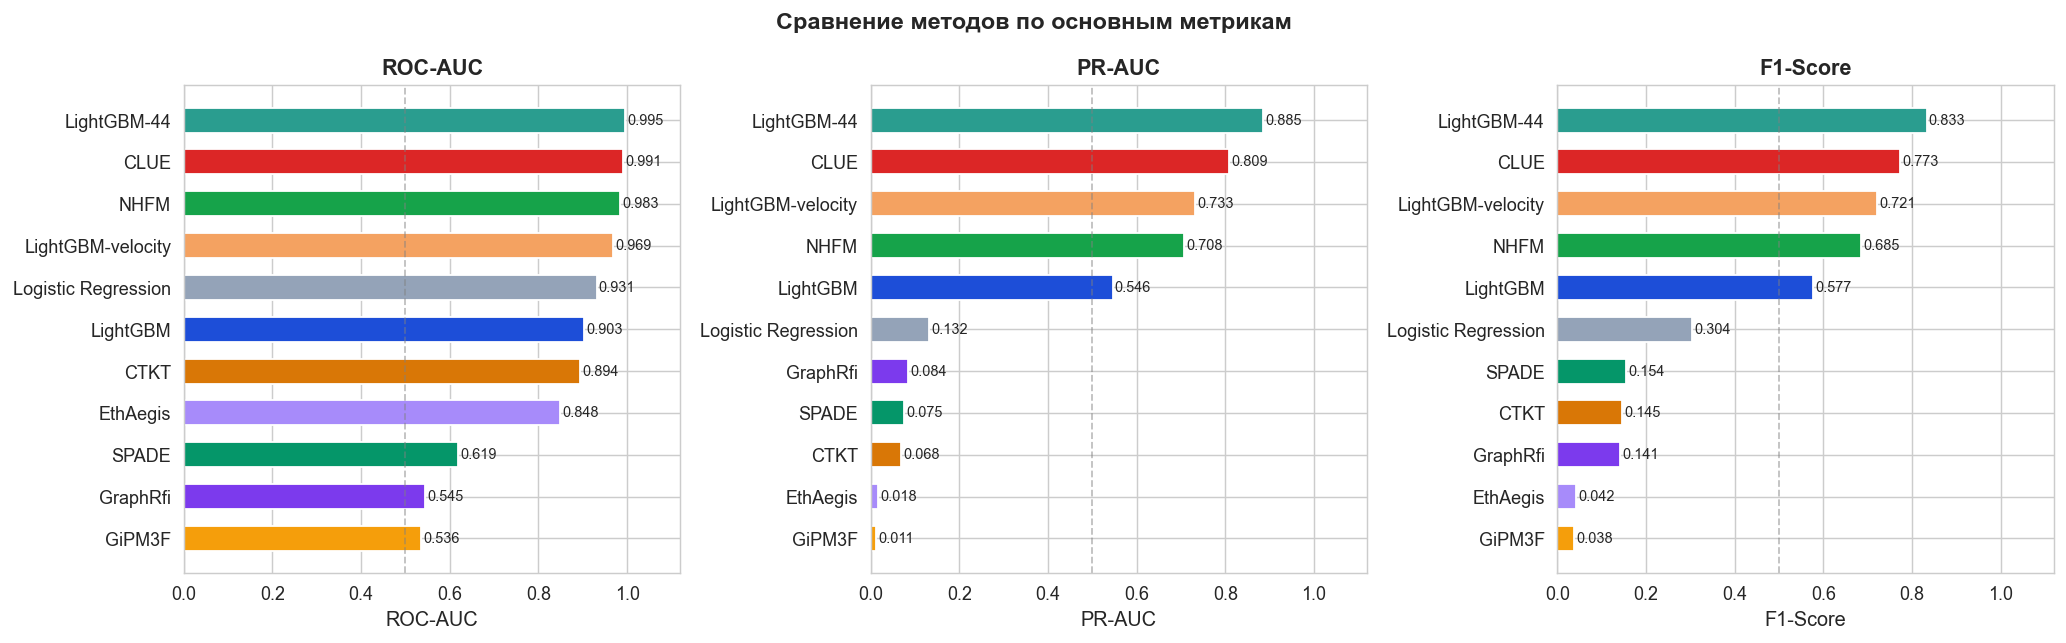

Барчарт сохранён: results/metrics_barplot.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_metrics = ["roc_auc", "pr_auc", "f1"]
plot_titles  = ["ROC-AUC", "PR-AUC", "F1-Score"]

for ax, metric, title in zip(axes, plot_metrics, plot_titles):
    methods_sorted = metrics_df[metric].sort_values(ascending=True)
    colors = [METHOD_META[m]["color"] for m in methods_sorted.index]
    labels = [METHOD_META[m]["label"] for m in methods_sorted.index]

    bars = ax.barh(labels, methods_sorted.values,
                   color=colors, edgecolor="white", height=0.6)

    # Подписи значений
    for bar, val in zip(bars, methods_sorted.values):
        ax.text(
            val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center", ha="left", fontsize=8,
        )

    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim([0, 1.12])
    ax.axvline(0.5, color="gray", linestyle="--",
               linewidth=1, alpha=0.5)

plt.suptitle("Сравнение методов по основным метрикам",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "metrics_barplot.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("Барчарт сохранён: results/metrics_barplot.png")

In [10]:
# Время инференса на полной тестовой выборке (555,719 транзакций)
# LR и LightGBM замерялись на батче 10,000 — пересчитываем на полный test
# ВСЕ замеры в этой таблице выполнены на Apple M1 (см. Notebooks 2-5).
TEST_SIZE  = 555_719
BATCH_SIZE = 10_000
scale      = TEST_SIZE / BATCH_SIZE

lr_total_s   = (1.8   / 1000) * scale
lgbm_total_s = (155.9 / 1000) * scale

inference_times = {
    "lr":       lr_total_s,
    "lgbm":     lgbm_total_s,
    "ctkt":     35.5,
    "gipm3f":   8.1,
    "graphrfi": 9.8,
    "ethaegis": 120.0,
    "spade":    31.4,
    "clue":     76.5,
    "nhfm":     76.7,
    # lgbm_velocity и lgbm_44 сознательно НЕ включены: их замеры
    # выполнены на Apple M4 Pro (55.2 и 90.0 мс на батче 10,000)
    # и с M1-замерами напрямую не сопоставимы
}

print("Время инференса на тестовой выборке (555,719 транзакций):\n")
print(f"  {'Метод':<25} {'Время':>10}  {'мс/транзакцию':>15}")
print("-" * 55)
for method, t in sorted(inference_times.items(),
                        key=lambda x: x[1]):
    label    = METHOD_META[method]["label"]
    ms_per_t = (t * 1000) / TEST_SIZE
    print(f"  {label:<25} {t:>8.2f}s  {ms_per_t:>13.4f} мс")

# Добавляем в таблицу метрик; у lgbm_velocity и lgbm_44 будет NaN —
# это ожидаемо (см. примечание ниже)                      # <--
metrics_df["inference_s"] = metrics_df.index.map(inference_times)
metrics_df["ms_per_txn"]  = (metrics_df["inference_s"] * 1000) / TEST_SIZE

print(f"\nПримечание: LR и LightGBM пересчитаны с батча {BATCH_SIZE:,} "
      f"на полный test {TEST_SIZE:,} транзакций")
print(f"  Коэффициент масштабирования: {scale:.1f}x")
print("  LightGBM-velocity и LightGBM-44 в таблицу не включены: "
      "замер на другом устройстве (M4 Pro)")                # <--

Время инференса на тестовой выборке (555,719 транзакций):

  Метод                          Время    мс/транзакцию
-------------------------------------------------------
  Logistic Regression           0.10s         0.0002 мс
  GiPM3F                        8.10s         0.0146 мс
  LightGBM                      8.66s         0.0156 мс
  GraphRfi                      9.80s         0.0176 мс
  SPADE                        31.40s         0.0565 мс
  CTKT                         35.50s         0.0639 мс
  CLUE                         76.50s         0.1377 мс
  NHFM                         76.70s         0.1380 мс
  EthAegis                    120.00s         0.2159 мс

Примечание: LR и LightGBM пересчитаны с батча 10,000 на полный test 555,719 транзакций
  Коэффициент масштабирования: 55.6x
  LightGBM-velocity и LightGBM-44 в таблицу не включены: замер на другом устройстве (M4 Pro)


In [11]:
# Пересчёт времени инференса на батч 10,000 транзакций
# для соответствия постановке задачи курсовой работы
BATCH_SIZE = 10_000
TEST_SIZE  = 555_719
scale      = BATCH_SIZE / TEST_SIZE  # ~0.018x

inference_batch = {
    method: t * scale
    for method, t in inference_times.items()
}

# LR и LightGBM уже были замерены на батче 10K — берём исходные значения
inference_batch["lr"]   = 1.8   / 1000   # 1.8 мс → секунды
inference_batch["lgbm"] = 155.9 / 1000   # 155.9 мс → секунды

print("Время инференса на батче 10,000 транзакций:\n")
print(f"  {'Метод':<25} {'Время (с)':>10}  {'Время (мс)':>12}")
print("-" * 52)
for method, t in sorted(inference_batch.items(), key=lambda x: x[1]):
    label = METHOD_META[method]["label"]
    print(f"  {label:<25} {t:>10.4f}s  {t*1000:>10.2f} мс")

# Обновляем в таблице метрик
metrics_df["inference_batch_s"]  = metrics_df.index.map(inference_batch)
metrics_df["inference_batch_ms"] = metrics_df["inference_batch_s"] * 1000

print(f"\nБатч: {BATCH_SIZE:,} транзакций")
print(f"Порог практической применимости: <несколько сотен мс")

Время инференса на батче 10,000 транзакций:

  Метод                      Время (с)    Время (мс)
----------------------------------------------------
  Logistic Regression           0.0018s        1.80 мс
  GiPM3F                        0.1458s      145.76 мс
  LightGBM                      0.1559s      155.90 мс
  GraphRfi                      0.1763s      176.35 мс
  SPADE                         0.5650s      565.03 мс
  CTKT                          0.6388s      638.81 мс
  CLUE                          1.3766s     1376.60 мс
  NHFM                          1.3802s     1380.19 мс
  EthAegis                      2.1594s     2159.36 мс

Батч: 10,000 транзакций
Порог практической применимости: <несколько сотен мс


> **Примечание.** LightGBM-velocity и LightGBM-44 в сравнение времени не включены:
> их замеры выполнены на другом устройстве (Apple M4 Pro: 55,2 и 90,0 мс на батче
> 10 000) и с M1-замерами остальных методов напрямую не сопоставимы. Архитектурно
> обе конфигурации идентичны базовому LightGBM и укладываются в те же требования
> реального времени.

## 7. Итоговые выводы

### 7.1 Основные результаты

Иерархия методов по PR-AUC устойчива: все ключевые попарные различия
значимы по парному бутстрэпу разностей (ноль вне 95%-х интервалов).

**LightGBM-44 (32 статических + 12 velocity-признаков) — лучший результат
эксперимента:** PR-AUC = 0,885 [0,874; 0,896], ROC-AUC = 0,995,
Precision@500 = 1,0. Разность с CLUE значима: ΔPR-AUC = [+0,070; +0,099].

**Последовательные нейросетевые методы** остаются сильнейшими среди
подходов без конструирования признаков. CLUE достигает PR-AUC = 0,809 на
пяти сырых дискретизированных атрибутах, значимо опережая бустинг на
двенадцати сконструированных временны́х признаках
(CLUE − LGBM-velocity: [+0,052; +0,084]). NHFM — 0,708.

**Абляция трёх конфигураций бустинга** разделяет вклады признаковых групп
при идентичных гиперпараметрах:

| Конфигурация | Признаки | PR-AUC |
|---|---|---|
| LightGBM-32 | статика | 0,546 [0,525; 0,567] |
| LightGBM-velocity | только динамика | 0,733 [0,715; 0,751] |
| LightGBM-44 | статика + динамика | 0,885 [0,874; 0,896] |

Чистый временно́й сигнал значимо сильнее чистого статического
([+0,162; +0,211]), а их комбинация сильнее каждой группы по отдельности —
сигналы комплементарны. В velocity-конфигурации доминирует `amt_roll_z`
(отклонение суммы от скользящего профиля держателя), тогда как частотный
счётчик `cnt_1h` практически не используется: фрод в Sparkov проявляется
как отклонение от персонального профиля, а не как высокочастотный «прогон»
карты.

**Графовые и факторизационные методы** показывают ограниченное качество
из-за структурных особенностей синтетики: 77,5% держателей имеют хотя бы
одну мошенническую транзакцию в train, что делает узловые метки графа
малоинформативными. CTKT — исключение по ROC-AUC (0,894) при низком
PR-AUC (0,068).

**Устойчивость к асимметрии стоимостей ошибок.** Ранжирование методов
практически не зависит от выбора между F1, F2 и F0.5 (корреляции Спирмена
рангов 0,991 и 0,936). Денежно-взвешенный Recall@500 у лидеров выше
штучного (CLUE: 35,2% ущерба против 23,1% транзакций; LightGBM-velocity:
37,5%): очередь алертов накрывает непропорционально крупный фрод, то есть
в терминах предотвращённого ущерба методы ещё эффективнее, чем в терминах
числа выявленных транзакций.

### 7.2 Ответ на исследовательский вопрос

**Решающим фактором качества на данных Sparkov является доступ модели
к временно́й динамике поведения держателя, а не класс архитектуры сам
по себе.** Это подтверждено двумя независимыми способами: (1) внутри
одного класса моделей — velocity-признаки поднимают бустинг с 0,546 до
0,885; (2) между классами — нейросетевое моделирование порядка (CLUE)
извлекает из пяти сырых атрибутов больше, чем бустинг из двенадцати
сконструированных временны́х признаков.

Мошенническое поведение проявляется прежде всего как отклонение от
индивидуального поведенческого паттерна во времени, а не как статическая
аномалия в пространстве признаков. При этом носитель временно́го сигнала
может быть разным: тщательный velocity-инжиниринг в комбинации со статикой
дал на Sparkov лучший результат, а явное нейросетевое моделирование
порядка — лучший результат без конструирования признаков.

Методы, адаптированные из смежных доменов рекомендательных систем,
конкурентоспособны в верхней части очереди алертов (GraphRfi:
Precision@100 = 1,0), однако их глобальное качество ограничено
особенностями данных.

### 7.3 Ограничения эксперимента

- **Синтетический датасет** — Sparkov не обладает рядом свойств реальных
  данных: сетевыми паттернами фрода, устойчивыми персональными
  поведенческими паттернами, реалистичной долей мошеннических аккаунтов.
  Все выводы условны на датасет; воспроизведение на данных с явными
  идентификаторами сторон (IEEE-CIS, PaySim) — направление дальнейшей
  работы.
- **Гиперпараметры трёх конфигураций бустинга** идентичны и подобраны
  Optuna под 32-мерное статическое пространство. Это осознанное решение
  для изоляции вклада признаковых групп, однако для velocity-only
  конфигурации параметры могут быть неоптимальны.
- **Вычислительные ресурсы** — ряд адаптаций (IBP в GiPM3F, полный PAG
  в EthAegis, NRF в GraphRfi) заменён на более простые аналоги.
- **Однократное временно́е разбиение** — бутстрэп-интервалы характеризуют
  устойчивость к составу тестовой выборки, но не к выбору обучающего
  периода.

## 8. Графики для публикации

Версии рисунков, подготовленные под требования журнала: монохромное исполнение (линии различаются типом штриха и маркером, а не цветом), разрешение 300 dpi, форматы EPS и TIFF. Содержательно повторяют рисунки из разделов выше; барчарт основных метрик в публикацию не включается, поскольку дублирует сводную таблицу.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


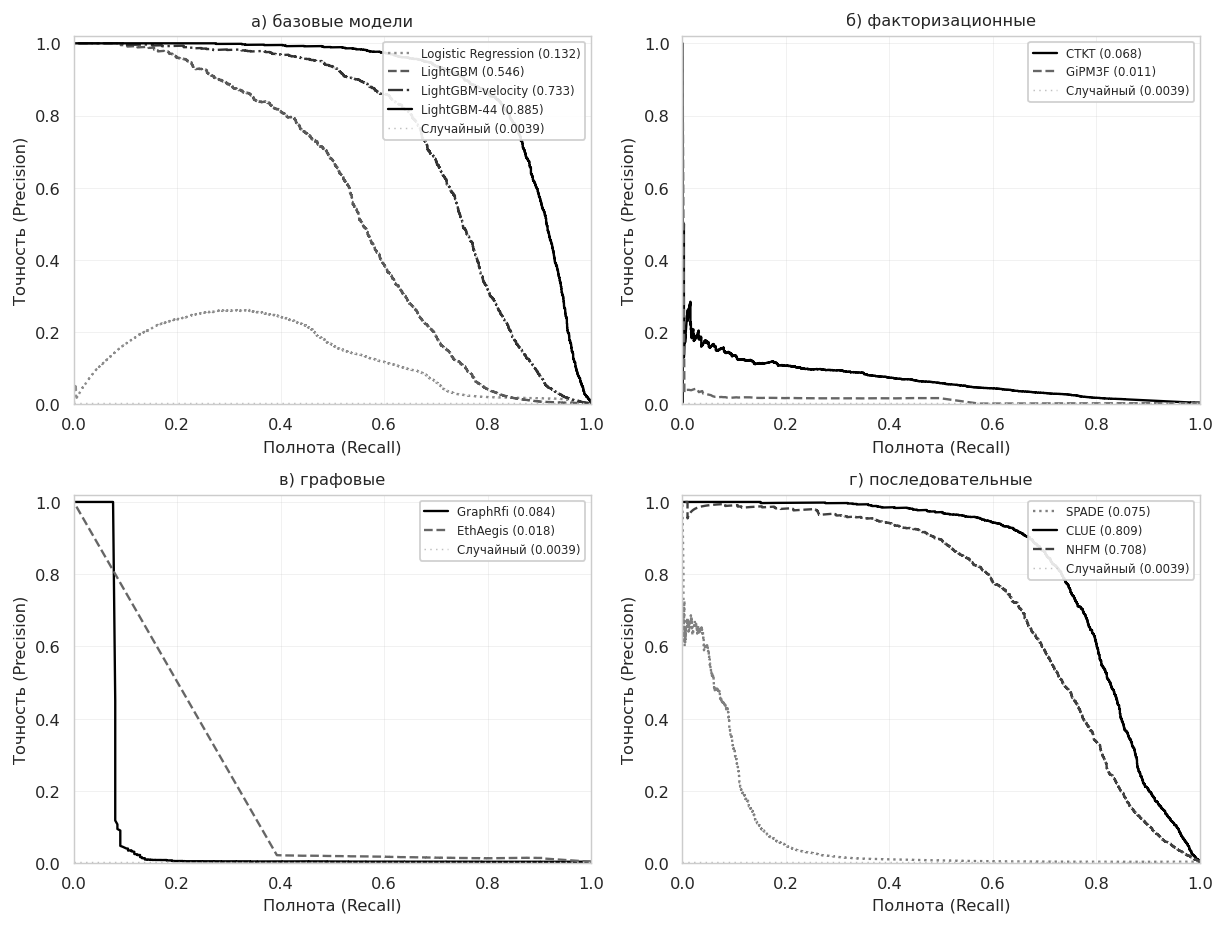

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


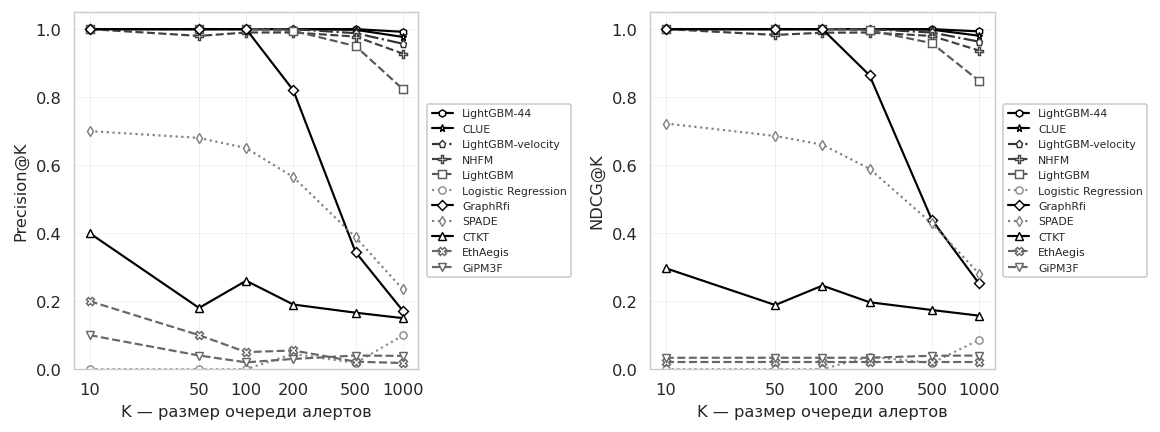

Рисунки для публикации сохранены в ../results/publication/


In [12]:
# Рисунки для публикации (монохромная печать)
# Требования журнала: EPS/TIFF 300 dpi, различение линий типом штриха,
# читаемость без цвета.

PUB = RESULTS / "publication"
PUB.mkdir(exist_ok=True)

PUB_STYLE = {
    # а) базовые — четыре разных штриха, лидер чёрный сплошной
    "lr":            {"ls": ":",                "marker": "o", "gray": 0.55},
    "lgbm":          {"ls": "--",               "marker": "s", "gray": 0.35},
    "lgbm_velocity": {"ls": "-.",               "marker": "p", "gray": 0.20},
    "lgbm_44":       {"ls": "-",                "marker": "h", "gray": 0.00},
    # б) факторизационные
    "ctkt":          {"ls": "-",                "marker": "^", "gray": 0.00},
    "gipm3f":        {"ls": "--",               "marker": "v", "gray": 0.40},
    # в) графовые
    "graphrfi":      {"ls": "-",                "marker": "D", "gray": 0.00},
    "ethaegis":      {"ls": "--",               "marker": "X", "gray": 0.40},
    # г) последовательные
    "clue":          {"ls": "-",                "marker": "*", "gray": 0.00},
    "nhfm":          {"ls": "--",               "marker": "P", "gray": 0.25},
    "spade":         {"ls": ":",                "marker": "d", "gray": 0.50},
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "savefig.dpi": 300,
})

# Рисунок 1: PR-кривые по категориям — теперь 2x2, базовые отдельно
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.2))
axes = axes.ravel()
categories = {
    "а) базовые модели":        ["lr", "lgbm", "lgbm_velocity", "lgbm_44"],
    "б) факторизационные":      ["ctkt", "gipm3f"],
    "в) графовые":              ["graphrfi", "ethaegis"],
    "г) последовательные":      ["spade", "clue", "nhfm"],
}
for ax, (title, methods) in zip(axes, categories.items()):
    for m in methods:
        df = scores_dict[m]
        y, s = df["y_true"].values, df["score"].values
        prec, rec, _ = precision_recall_curve(y, s)
        st = PUB_STYLE[m]
        ax.plot(rec, prec, color=str(st["gray"]), linestyle=st["ls"],
                linewidth=1.3,
                label=f"{METHOD_META[m]['label']} ({average_precision_score(y, s):.3f})")
    ax.axhline(y.mean(), color="0.75", linestyle=(0, (1, 3)), linewidth=0.8,
               label=f"Случайный ({y.mean():.4f})")
    ax.set_xlabel("Полнота (Recall)")
    ax.set_ylabel("Точность (Precision)")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
for ext in ["eps", "tiff", "png"]:
    fig.savefig(PUB / f"fig1_pr_curves.{ext}", bbox_inches="tight", dpi=300)
plt.show()

# Рисунок 2: метрики ранжирования — 11 методов, легенда по убыванию PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
k_values = [10, 50, 100, 200, 500, 1000]
plot_order = metrics_df.sort_values("pr_auc", ascending=False).index

for ax, metric_name in zip(axes, ["Precision@K", "NDCG@K"]):
    for m in plot_order:
        if m not in scores_dict:
            continue
        df = scores_dict[m]
        y, s = df["y_true"].values, df["score"].values
        y_ranked = y[np.argsort(s)[::-1]]
        st = PUB_STYLE[m]
        vals = [y_ranked[:k].mean() if metric_name == "Precision@K"
                else ndcg_score(y.reshape(1, -1), s.reshape(1, -1), k=k)
                for k in k_values]
        ax.plot(k_values, vals, color=str(st["gray"]), linestyle=st["ls"],
                marker=st["marker"], markersize=4, linewidth=1.2,
                markerfacecolor="white", markeredgewidth=0.8,
                label=METHOD_META[m]["label"])
    ax.set_xlabel("K — размер очереди алертов")
    ax.set_ylabel(metric_name)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks(k_values)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6, loc="center left", bbox_to_anchor=(1.01, 0.5),
              framealpha=0.9)

plt.tight_layout()
for ext in ["eps", "tiff", "png"]:
    fig.savefig(PUB / f"fig2_ranking_metrics.{ext}", bbox_inches="tight", dpi=300)
plt.show()

print(f"Рисунки для публикации сохранены в {PUB}/")